## **Scrapping Data**

In [ ]:
!pip uninstall -y numpy scipy gensim transformers umap-learn hdbscan wordcloud bertopic sentence-transformers
!pip uninstall -y numpy


Found existing installation: numpy 1.25.2
Uninstalling numpy-1.25.2:
  Successfully uninstalled numpy-1.25.2
Found existing installation: scipy 1.9.3
Uninstalling scipy-1.9.3:
  Successfully uninstalled scipy-1.9.3
Found existing installation: gensim 4.3.2
Uninstalling gensim-4.3.2:
  Successfully uninstalled gensim-4.3.2
Found existing installation: transformers 4.52.4
Uninstalling transformers-4.52.4:
  Successfully uninstalled transformers-4.52.4
Found existing installation: umap-learn 0.5.7
Uninstalling umap-learn-0.5.7:
  Successfully uninstalled umap-learn-0.5.7
Found existing installation: hdbscan 0.8.40
Uninstalling hdbscan-0.8.40:
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 105, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 96, in _inner_run
    return se

## **Text Data Preprocessing**

In [ ]:
pip install --upgrade numpy umap-learn hdbscan bertopic wordcloud


In [ ]:
import numpy as np
print("NumPy version:", np.__version__)


NumPy version: 1.25.2


In [ ]:
!pip install --upgrade pip
!pip cache purge


Files removed: 38 (79.5 MB)


In [ ]:
!pip install Sastrawi

In [ ]:
import pandas as pd
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Load Dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/Kumpulan dataset/scraping_berita.csv'

# Membaca dataset
df = pd.read_csv(file_path)





In [ ]:
len(df['Isi'])

474

In [ ]:
# Untuk menyimpan informasi awal berita
df['original_text'] = df['Isi']
df= df.drop_duplicates(subset='original_text')
len(df['original_text'])
df = df[df['original_text'].str.len() > 50]

In [ ]:
# 2. Filter Data Tidak Valid
df = df[(df['Isi'] != 'Konten tidak ditemukan')]
len(df)

276

In [ ]:
# Preprocessung menggunakan kolom isi
# 3. Inisialisasi Tools NLP Bahasa Indonesia
factory = StemmerFactory()
stemmer = factory.create_stemmer()
stopword_factory = StopWordRemoverFactory()
stopword = stopword_factory.create_stop_word_remover()

# 4. Fungsi Preprocessing Teks
def preprocess_indonesian_text(text):
    try:

        text = re.sub(r'http[s]?://\S+|www\.\S+|\S+\.(com|org|net|id)\S*','',text) #menghapus yang ada .com
        text = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', text) #tambah spasi dua kata nyatu
        text = re.sub(r'(?<=[A-Z])(?=[A-Z][a-z])', ' ', text) #tambah spasi dua kata menyatu
        text = re.sub(r'\[Gambas:Video.*?\]', '', text)  # Hapus tag video
        text = re.sub(r'https?://\S+', '', text)  # Hapus URL
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)  # Hapus tanda baca
        text = re.sub(r'\s+', ' ', text)  # Hapus spasi berlebih
        text = text.strip().lower()  # Case folding
        text = re.sub(r'\d+', '', text) #hapus angka
        text = re.sub(r'http[s]?://\S+|www\.\S+|\S+\.(com|org|net|id)\S*','',text) #menghapus yang ada .com
        text = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', text) #tambah spasi dua kata nyatu
        text = re.sub(r'(?<=[A-Z])(?=[A-Z][a-z])', ' ', text) #tambah spasi dua kata menyatu
        text = re.sub(r'\b(\w+)( \1\b)+', r'\1', text, flags=re.IGNORECASE) # menghapus duplikat kata
        # Bersihkan teks
        # Daftar frasa yang ingin dihapus
        phrases_to_remove = [
            r'scroll to continue with content',
            r'advertisement',
            r'iklan',
            r'baca juga',
            r'baca',
            r'klik',
            r'wib',
            r'follow',
            r'baca',
            r'kisah',
            r'kisah',
            r'awards',
            r'awards',
            r'hoegeng',r'hari',r'whats',
            r'hoegeng', r'feri',r'mau',r'amnesty',r'app channel',
            r'sind',r'had',r'onews',r'macron',r'macron', r'prasetyo'

        ]

        # Hapus semua frasa tersebut
        for phrase in phrases_to_remove:
            text = re.sub(phrase, '', text, flags=re.IGNORECASE)



        # Stopword removal + stemming
        tokens = text.split()
        cleaned_tokens = []
        for token in tokens:
            if token not in stopword_factory.get_stop_words():  # Stopword removal
                stemmed = stemmer.stem(token)  # Stemming
                if len(stemmed) > 2:  # Hapus kata pendek
                    cleaned_tokens.append(stemmed)

        return ' '.join(cleaned_tokens)

    except:
        return ''

# 5. Terapkan Preprocessing ke Kolom Isi
df['cleaned_text'] = df['Isi'].apply(preprocess_indonesian_text)

# 6. Hapus Baris dengan Teks Kosong
df = df[df['cleaned_text'].str.len() > 50]

# 8. Tampilkan Contoh Hasil
print("\nContoh Teks Asli:")
print(df['Isi'].iloc[0][:200] + "...")

print("\nContoh Teks Hasil Preprocessing:")
print(df['cleaned_text'].iloc[0][:200] + "...")


Contoh Teks Asli:
Liputan6.com, Jakarta -Di tengah berbagai tantangan global dan dinamika sosial nasional, sejumlah tokoh bangsa menegaskan pentingnya menjaga persatuan dan membangun optimisme kolektif sebagai fondasi ...

Contoh Teks Hasil Preprocessing:
jakarta tengah bagai tantang global dinamika sosial nasional jumlah tokoh bangsa tegas penting jaga satu bangun optimisme kolektif fondasi wujud masa depan indonesiayang lebih baik narasi pesimistis i...


In [ ]:
len(df['cleaned_text'])

276

## **BERTopic**

In [ ]:
import numpy as np
print(np.__version__)
print(dir(np))  # cek apakah atribut 'dtypes' ada
print(hasattr(np, 'dtypes'))


1.25.2
['ALLOW_THREADS', 'BUFSIZE', 'CLIP', 'DataSource', 'ERR_CALL', 'ERR_DEFAULT', 'ERR_IGNORE', 'ERR_LOG', 'ERR_PRINT', 'ERR_RAISE', 'ERR_WARN', 'FLOATING_POINT_SUPPORT', 'FPE_DIVIDEBYZERO', 'FPE_INVALID', 'FPE_OVERFLOW', 'FPE_UNDERFLOW', 'False_', 'Inf', 'Infinity', 'MAXDIMS', 'MAY_SHARE_BOUNDS', 'MAY_SHARE_EXACT', 'NAN', 'NINF', 'NZERO', 'NaN', 'PINF', 'PZERO', 'RAISE', 'RankWarning', 'SHIFT_DIVIDEBYZERO', 'SHIFT_INVALID', 'SHIFT_OVERFLOW', 'SHIFT_UNDERFLOW', 'ScalarType', 'True_', 'UFUNC_BUFSIZE_DEFAULT', 'UFUNC_PYVALS_NAME', 'WRAP', '_CopyMode', '_NoValue', '_UFUNC_API', '__NUMPY_SETUP__', '__all__', '__builtins__', '__cached__', '__config__', '__deprecated_attrs__', '__dir__', '__doc__', '__expired_functions__', '__file__', '__former_attrs__', '__future_scalars__', '__getattr__', '__git_version__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_add_newdoc_ufunc', '_builtins', '_distributor_init', '_financial_names', '_get_promotion_state', '_g

In [ ]:
!pip install scipy==1.9.3
!pip install gensim==4.3.2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import pairwise_distances
from wordcloud import WordCloud
from gensim.models import Word2Vec

from umap import UMAP        # UMAP import dari umap-learn sekarang hanya `from umap import UMAP`
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from gensim.models.coherencemodel import CoherenceModel


In [ ]:
\w2v_pre ="/content/drive/MyDrive/Colab Notebooks/Kumpulan dataset/cc.id.300.vec"
from gensim.models import KeyedVectors
import numpy as np

# 1. Load pre-trained Word2Vec Bahasa Indonesia
w2v_model = KeyedVectors.load_word2vec_format(w2v_pre, binary=False)

# 2. Tokenisasi dokumen
documents = df['cleaned_text'].tolist()
tokenized_docs = [doc.split() for doc in documents]

# 3. Generate document embeddings dari pre-trained model
def get_doc_embedding(tokens):
    vectors = [w2v_model[word] for word in tokens if word in w2v_model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(w2v_model.vector_size)

doc_embeddings = np.array([get_doc_embedding(doc) for doc in tokenized_docs])


# 4. UMAP Dimensionality Reduction
umap_model = UMAP(
    n_components=5,
    n_neighbors=10,
    min_dist=0.01,
    metric='cosine',
    random_state=42
)
reduced_embeddings = umap_model.fit_transform(doc_embeddings)

# 5. HDBSCAN Clustering
hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    cluster_selection_epsilon=0.5,
    prediction_data=True
)

# 6. Initialize BERTopic
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=CountVectorizer(ngram_range=(1, 2)),
    calculate_probabilities=True,
    verbose=True
)

# 7. Fit Model
topics, probs = topic_model.fit_transform(
    documents=documents,
    embeddings=reduced_embeddings
)

# Atur tampilan agar semua isi kolom tampil tanpa dipotong
pd.set_option('display.max_colwidth', None)

# Tampilkan hasil
print("\n=== Topik yang Ditemukan ===")
topic_info = topic_model.get_topic_info()
print(topic_info)

2025-06-01 04:52:52,795 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-01 04:52:53,587 - BERTopic - Dimensionality - Completed ✓
2025-06-01 04:52:53,590 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-01 04:52:53,672 - BERTopic - Cluster - Completed ✓
2025-06-01 04:52:53,708 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-01 04:52:54,147 - BERTopic - Representation - Completed ✓



=== Topik yang Ditemukan ===
   Topic  Count                                        Name  \
0     -1      8           -1_prabowo_dialog_tokoh_indonesia   
1      0     52  0_indonesia_gelap_indonesia gelap_perintah   
2      1     52             1_mahasiswa_dprd_aksi_indonesia   
3      2     50      2_aksi_indonesia_massa_indonesia gelap   
4      3     39      3_aksi_indonesia_indonesia gelap_gelap   
5      4     22              4_demo_indonesia_jakarta_senin   
6      5     15  5_mahasiswa_aksi_indonesia_indonesia gelap   
7      6     14          6_prabowo_presiden_indonesia_didit   
8      7     14   7_jalan_medan merdeka_jalan medan_merdeka   
9      8     10              8_aksi_anggar_yogyakarta_didik   

                                                                                           Representation  \
0     [prabowo, dialog, tokoh, indonesia, gelap, indonesia gelap, kalau, publik, tokoh indonesia, sampai]   
1               [indonesia, gelap, indonesia gelap, perint

In [ ]:
# Buat DataFrame dari hasil topik dan dokumen
df_topics = pd.DataFrame({
    "Document": documents,
    "Topic": topics
})

# Contoh: Tampilkan dokumen yang masuk ke Topik 0
print("\n=== Dokumen dalam Topik 0 ===")
print(df_topics[df_topics["Topic"] == 0]["Document"])

# Atau loop untuk beberapa topik
for t in sorted(df_topics["Topic"].unique()):
    print(f"\n=== Topik {t} ===")
    docs_in_topic = df_topics[df_topics["Topic"] == t]["Document"]
    for i, doc in enumerate(docs_in_topic.head(5), 1):  # tampilkan 5 contoh
        print(f"{i}. {doc}")



=== Dokumen dalam Topik 0 ===
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [ ]:
# Misalkan df['original_text'] berisi dokumen asli
df_topics = pd.DataFrame({
    "Document": df['original_text'],  # Ganti dengan kolom 'original_text' yang berisi teks asli
    "Topic": topics
})

# Contoh: Tampilkan dokumen yang masuk ke Topik 0
print("\n=== Dokumen dalam Topik 0 ===")
print(df_topics[df_topics["Topic"] == 0]["Document"])

# Atau loop untuk beberapa topik
for t in sorted(df_topics["Topic"].unique()):
    print(f"\n=== Topik {t} ===")
    docs_in_topic = df_topics[df_topics["Topic"] == t]["Document"]
    for i, doc in enumerate(docs_in_topic.head(5), 1):  # tampilkan 5 contoh
        print(f"{i}. {doc}")



=== Dokumen dalam Topik 0 ===
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [ ]:
print(doc_embeddings)

[[-0.00156358 -0.01084506  0.01564445 ... -0.05816608 -0.01165987
   0.05296604]
 [ 0.01037472 -0.00418415  0.02075358 ... -0.0433868  -0.01152566
   0.05660488]
 [ 0.00874116 -0.00882348  0.01511267 ... -0.04221952 -0.00755646
   0.05131397]
 ...
 [ 0.00930082  0.00413361  0.00866473 ... -0.05742116 -0.01474564
   0.05522489]
 [ 0.00983433  0.00037554  0.00598798 ... -0.06173047 -0.02177297
   0.05078239]
 [ 0.00429663 -0.00129438  0.01415225 ... -0.0495972  -0.01453596
   0.04816683]]


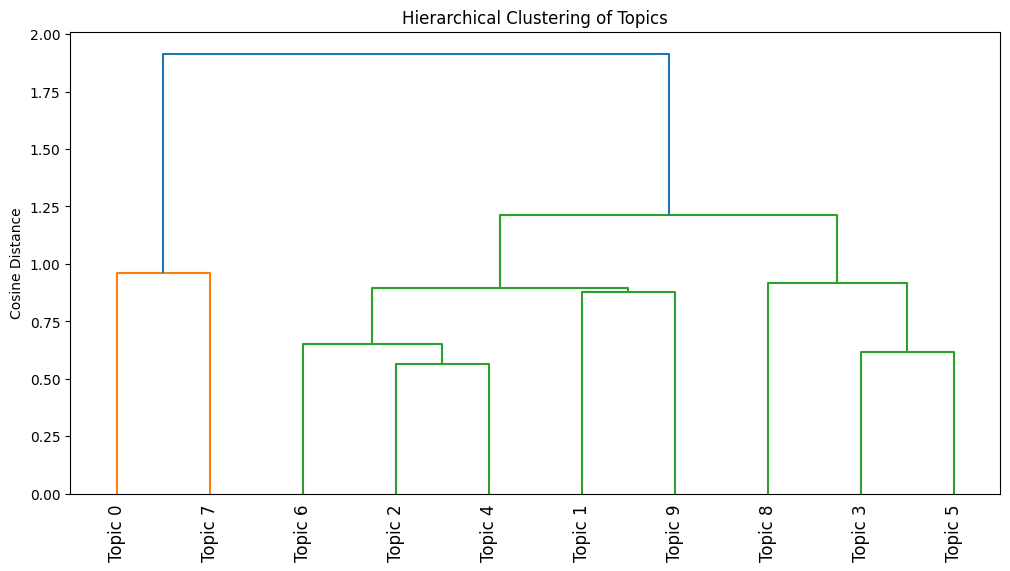

In [ ]:
num_topics = topic_model.c_tf_idf_.shape[0]
labels = [f"Topic {i}" for i in range(num_topics)]

# Hitung similarity antar topik
topic_embeddings = topic_model.c_tf_idf_.toarray()
cosine_sim = 1 - pairwise_distances(topic_embeddings, metric='cosine')

# Buat hierarchical clustering
Z = linkage(cosine_sim, 'ward')

# Visualisasi dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z,
           labels=labels,
           orientation='top',
           leaf_rotation=90)
plt.title("Hierarchical Clustering of Topics")
plt.ylabel("Cosine Distance")
plt.show()


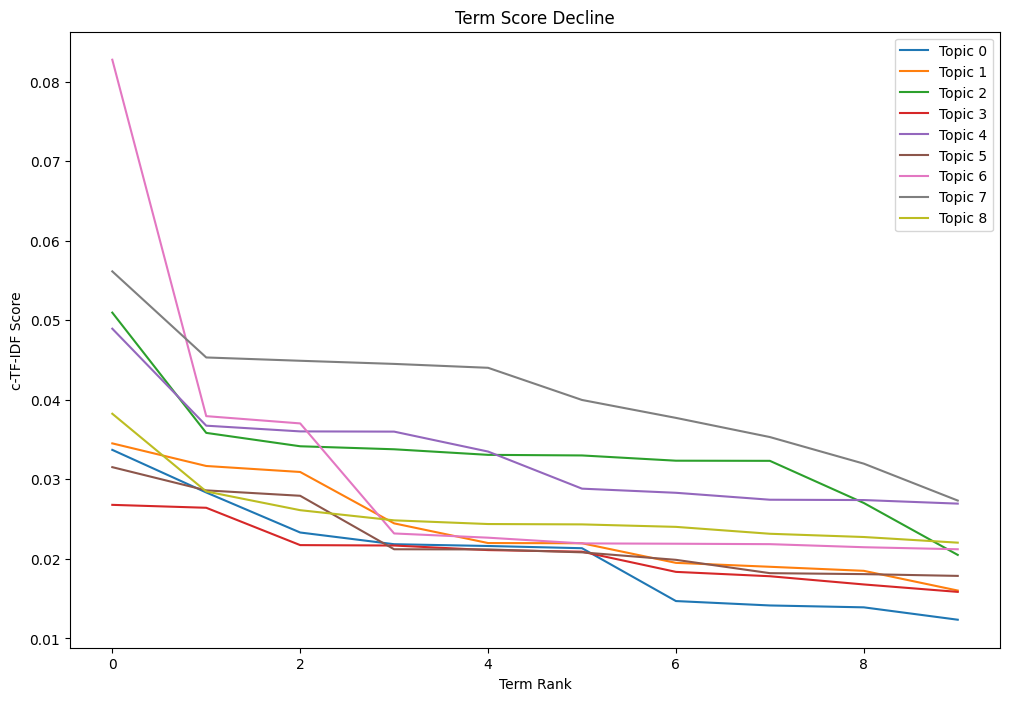

In [ ]:
# 3. Term Score Decline per Topic
plt.figure(figsize=(12, 8))
for topic in topic_info['Topic']:
    if topic != -1:  # Skip outlier topic
        scores = [score for _, score in topic_model.get_topic(topic)]
        plt.plot(scores, label=f'Topic {topic}')
plt.title("Term Score Decline")
plt.xlabel("Term Rank")
plt.ylabel("c-TF-IDF Score")
plt.legend()
plt.show()

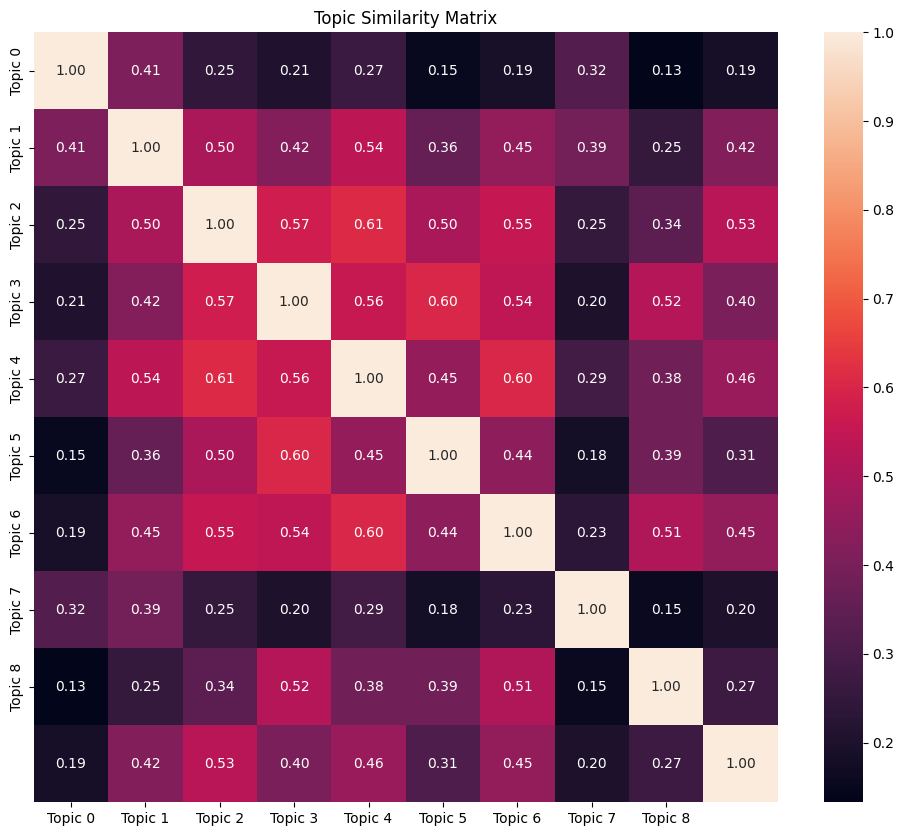

In [ ]:
# Filter out topic -1
topic_info_filtered = topic_info[topic_info.Topic != -1]

# Gunakan nilai asli dari kolom Topic sebagai label
labels = [f"Topic {t}" for t in topic_info_filtered["Topic"]]

# Plot dengan label yang sesuai
plt.figure(figsize=(12, 10))
sns.heatmap(cosine_sim,
            annot=True,
            fmt=".2f",
            xticklabels=labels,
            yticklabels=labels)
plt.title("Topic Similarity Matrix")
plt.show()


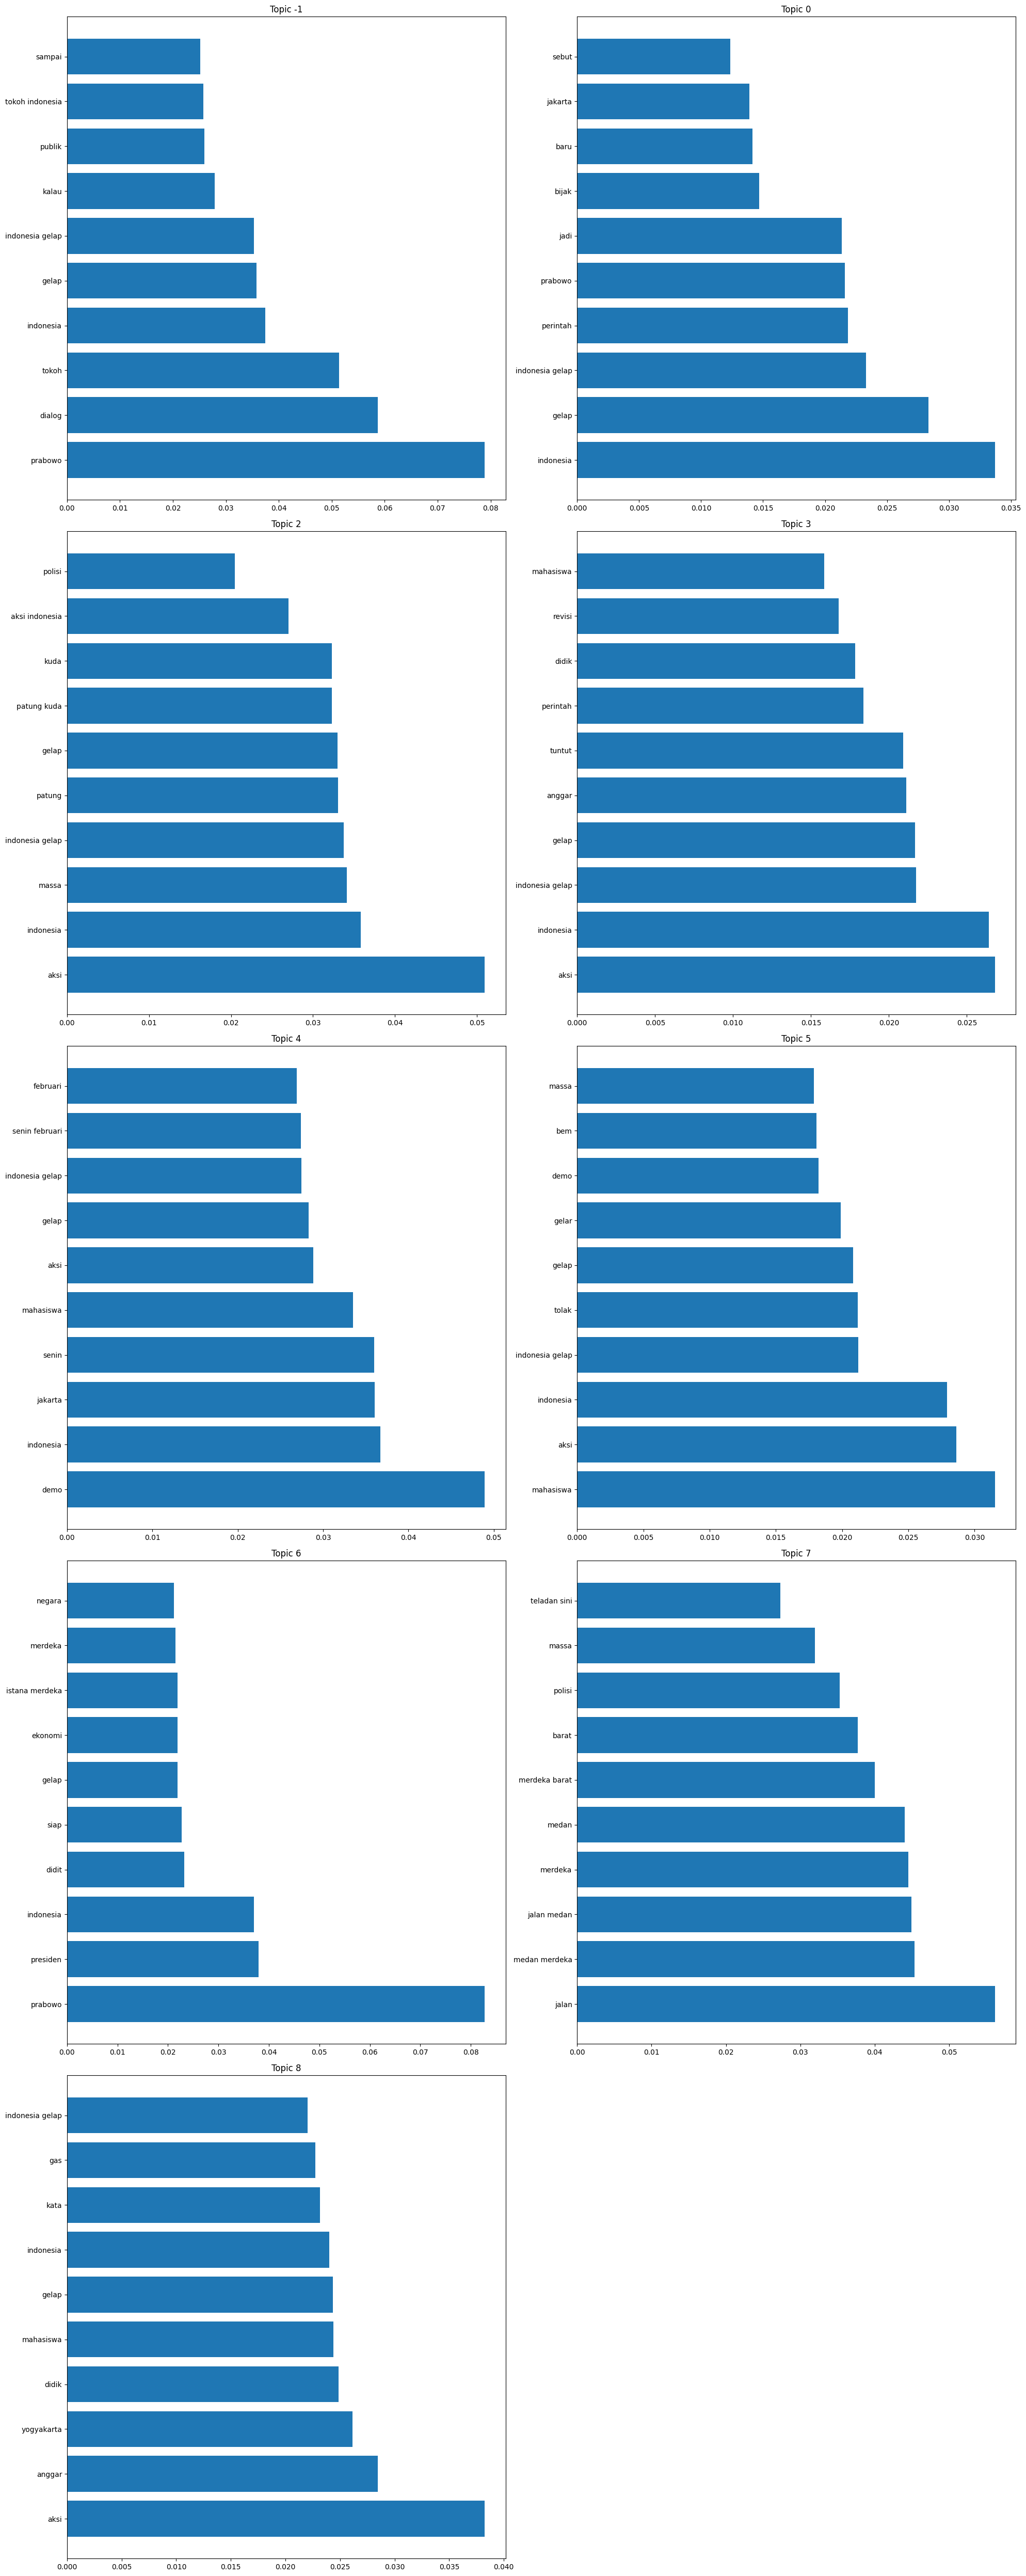

In [ ]:
# 5. Topic Word Scores
# DENGAN TIDAK MEMFILTER OUTLIER ALIAS TOPIK -1
# First calculate how many valid topics you have (excluding -1)
valid_topics = [t for t in topic_info['Topic'] if t != 1]
num_topics = len(valid_topics)

# Create a grid that can accommodate all topics
nrows = int(np.ceil(num_topics / 2))  # 2 columns, adjust as needed
ncols = 2

# Create appropriately sized figure
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows*10))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each valid topic
for i, topic in enumerate(valid_topics):
    ax = axes[i]
    words = [word for word, _ in topic_model.get_topic(topic)]
    scores = [score for _, score in topic_model.get_topic(topic)]
    ax.barh(words, scores)
    ax.set_title(f"Topic {topic}")

# Hide any unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

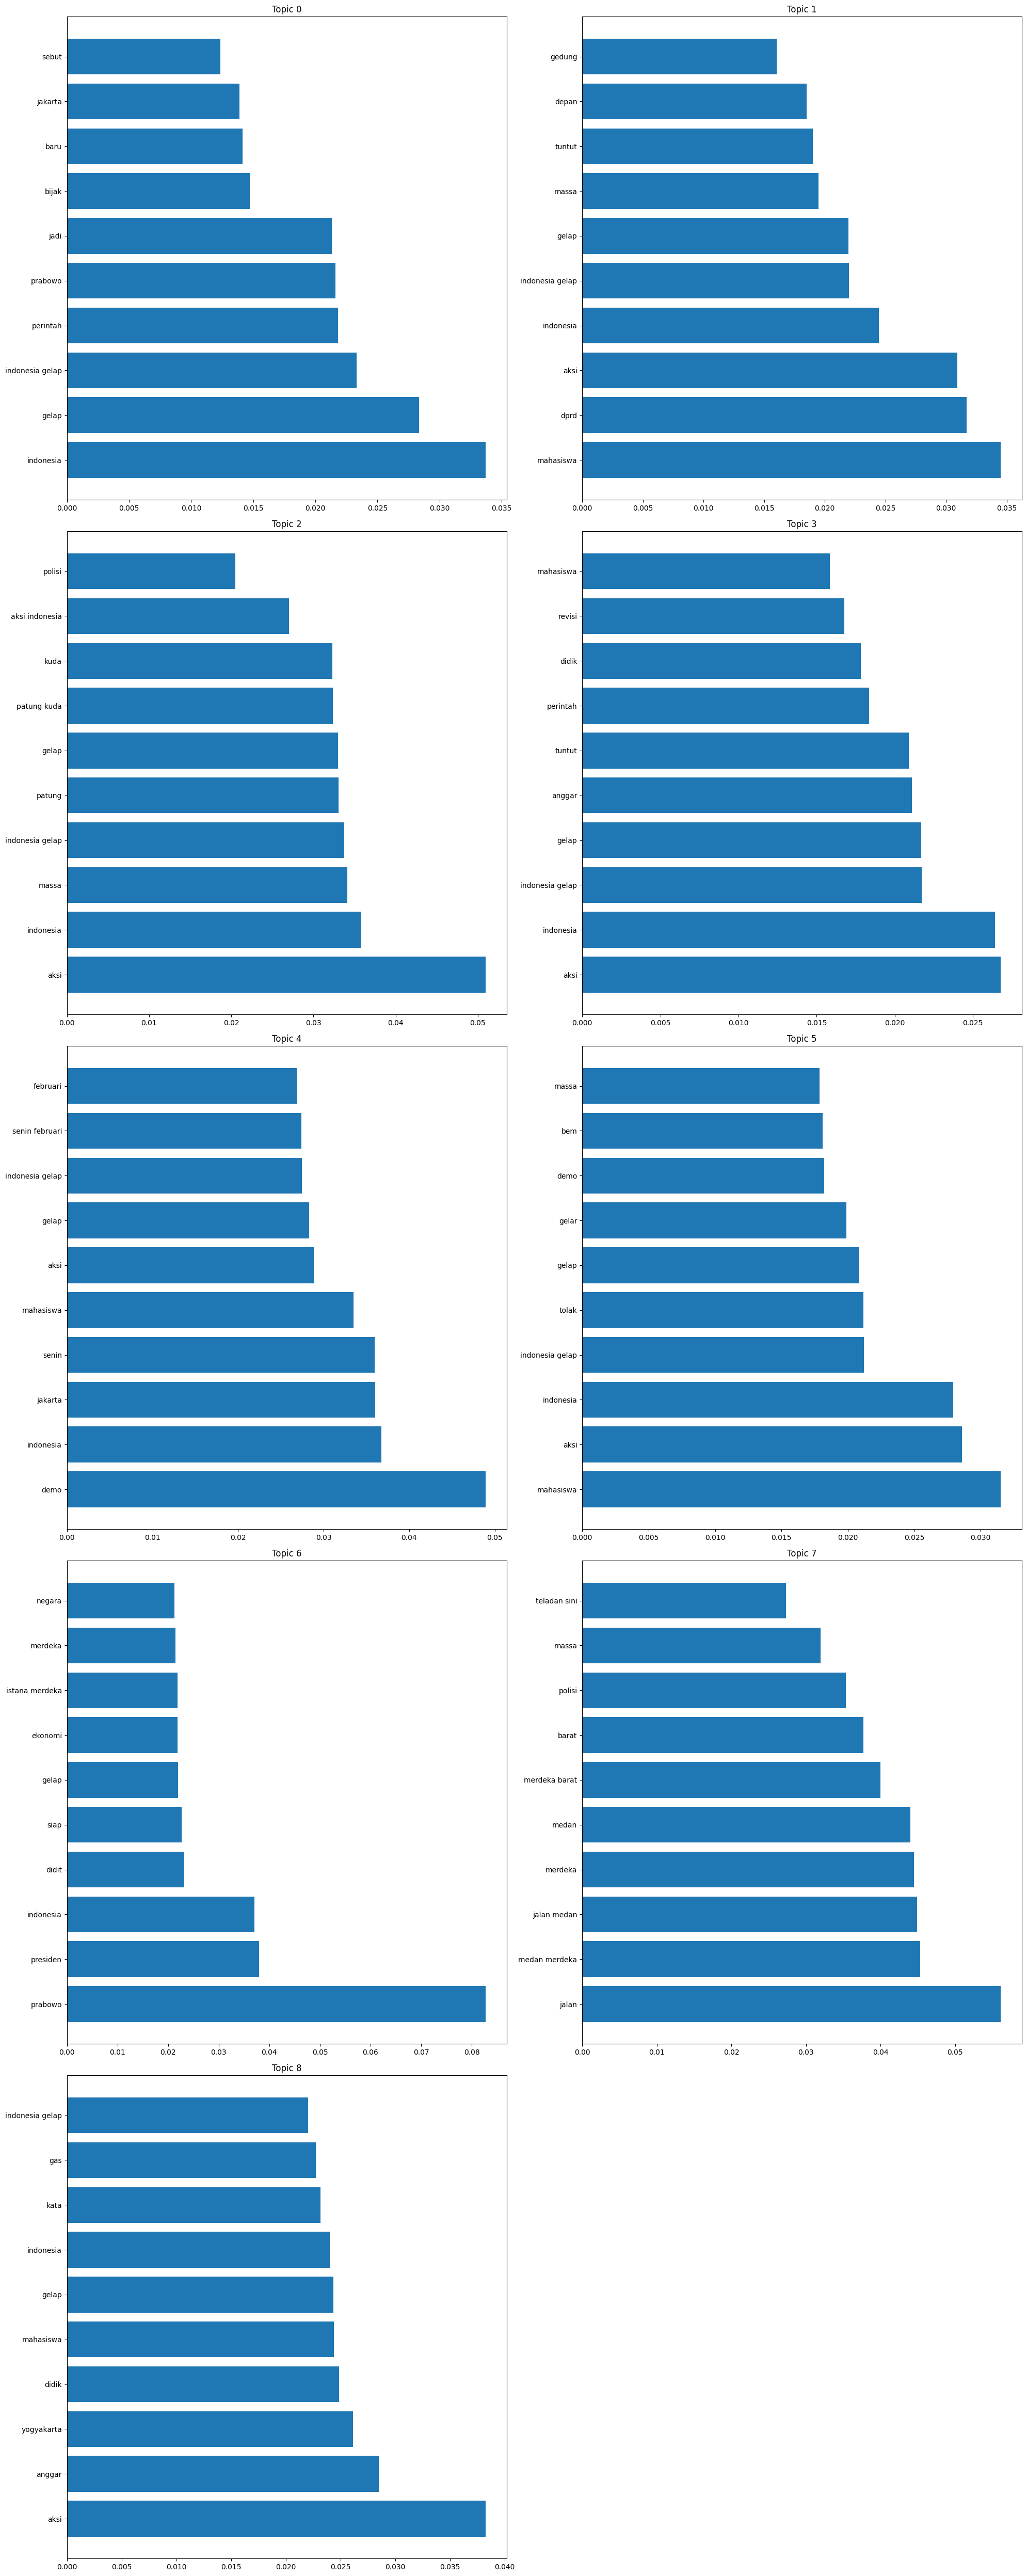

In [ ]:
# 5. Topic Word Scores
# DENGAN MEMFILTER OUTLIER ALIAS TOPIK -1
# First calculate how many valid topics you have (excluding -1)
valid_topics = [t for t in topic_info['Topic'] if t != -1]
num_topics = len(valid_topics)

# Create a grid that can accommodate all topics
nrows = int(np.ceil(num_topics / 2))  # 2 columns, adjust as needed
ncols = 2

# Create appropriately sized figure
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows*10))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each valid topic
for i, topic in enumerate(valid_topics):
    ax = axes[i]
    words = [word for word, _ in topic_model.get_topic(topic)]
    scores = [score for _, score in topic_model.get_topic(topic)]
    ax.barh(words, scores)
    ax.set_title(f"Topic {topic}")

# Hide any unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

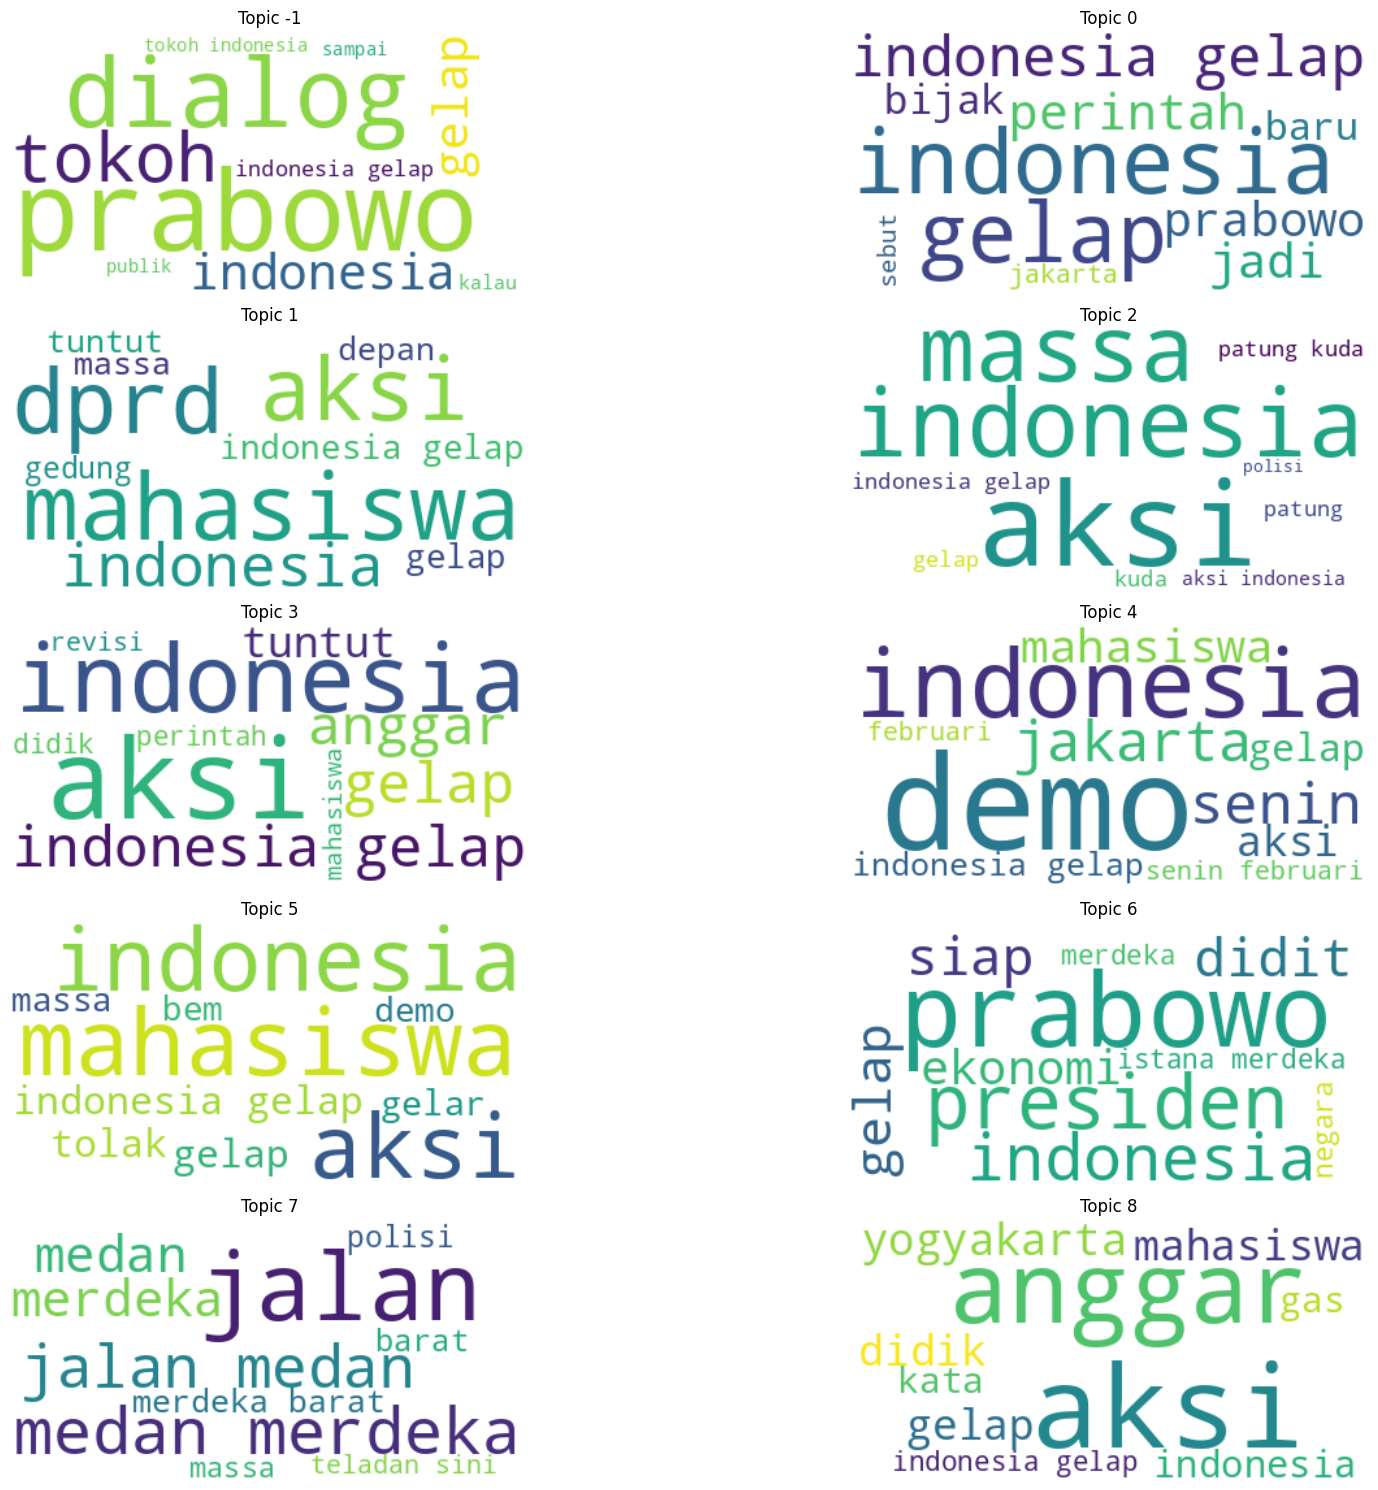

In [ ]:
import math
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Mendapatkan daftar topik yang valid
valid_topics = [t for t in topic_info['Topic']]
n_topics = len(valid_topics)
cols = 2
rows = math.ceil(n_topics / cols)

plt.figure(figsize=(20, rows * 3))

for i, topic in enumerate(valid_topics):
    plt.subplot(rows, cols, i + 1)

    # Mengambil kata-kata untuk topik tertentu
    topic_words = dict(topic_model.get_topic(topic))

    # Pastikan bahwa topik tidak kosong
    if len(topic_words) == 0:
        print(f"Topik {topic} kosong")
        continue

    # Generate word cloud dari frekuensi kata
    wordcloud = WordCloud(background_color='white').generate_from_frequencies(topic_words)

    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Topic {topic}")
    plt.axis("off")

plt.tight_layout()
plt.show()


1      0     57          0_indonesia_prabowo_gelap_indonesia gelap   
2      1     49                    1_mahasiswa_dprd_aksi_indonesia   
3      2     41             2_aksi_indonesia_indonesia gelap_gelap   
4      3     34                    3_indonesia_mahasiswa_demo_hari   

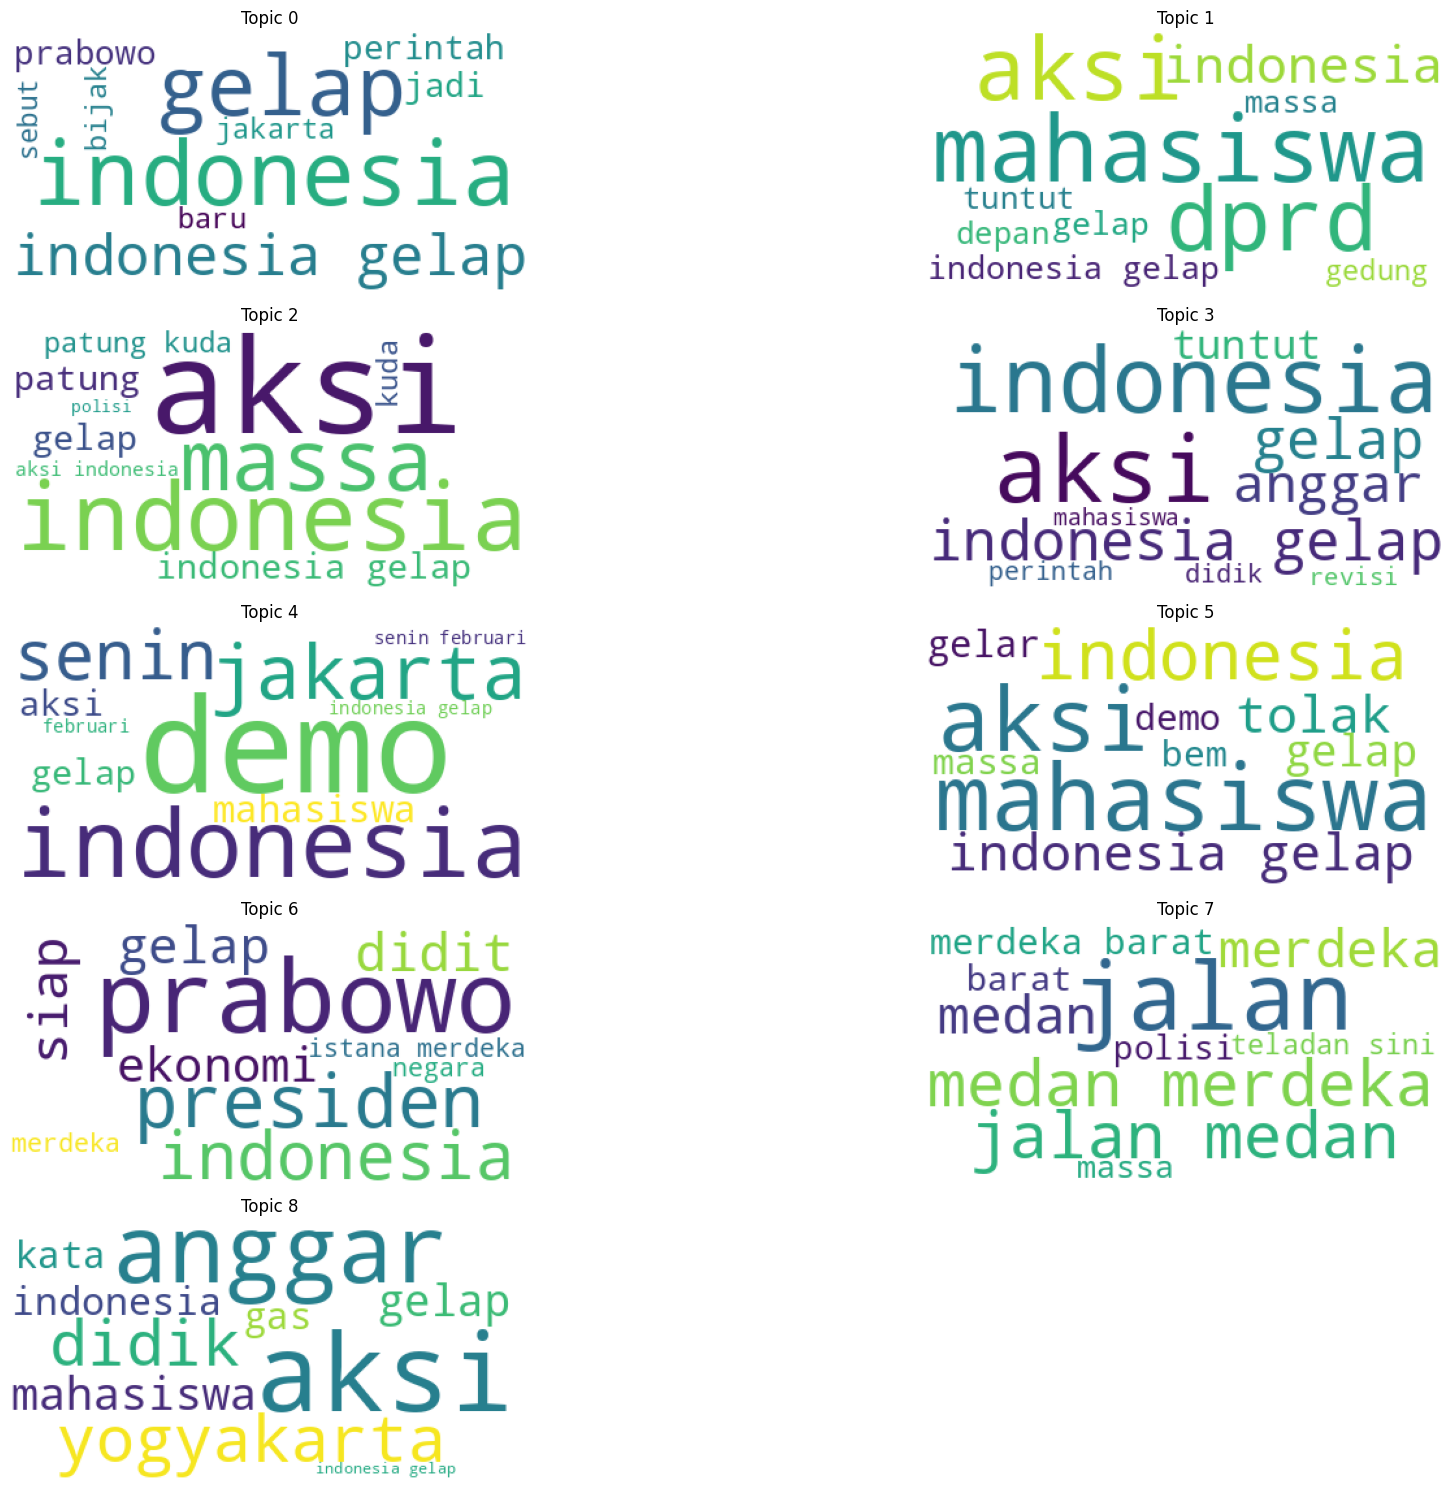

In [ ]:
import math
valid_topics = [t for t in topic_info['Topic'] if t != -1]
n_topics = len(valid_topics)
cols = 2
rows = math.ceil(n_topics / cols)

plt.figure(figsize=(20, rows * 3))

for i, topic in enumerate(valid_topics):
    plt.subplot(rows, cols, i + 1)
    wordcloud = WordCloud(background_color='white')
    topic_words = dict(topic_model.get_topic(topic))
    if len(topic_words) == 0:
        print(f"Topik {topic} kosong")
        continue
    plt.imshow(wordcloud.generate_from_frequencies(topic_words))
    plt.title(f"Topic {topic}")
    plt.axis("off")

plt.tight_layout()
plt.show()


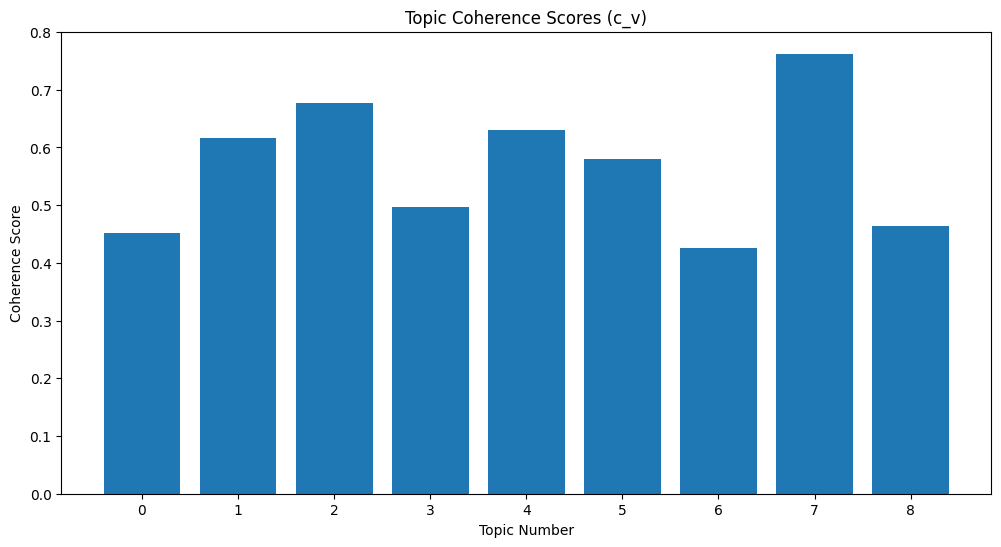

In [ ]:
# 7. Topic Coherence
from gensim.corpora import Dictionary

# Siapkan dictionary yang benar
dictionary = Dictionary(tokenized_docs)

# Siapkan data untuk coherence calculation
topics_list = [[word for word, _ in topic_model.get_topic(topic)]
              for topic in topic_info['Topic'] if topic != -1]

# Hitung coherence score
coherence_model = CoherenceModel(
    topics=topics_list,
    texts=tokenized_docs,
    dictionary=dictionary,  # Gunakan dictionary yang benar
    coherence='c_v',
    topn=10
)

coherence_scores = coherence_model.get_coherence_per_topic()

# Visualisasi coherence score
plt.figure(figsize=(12, 6))
valid_topics = [topic for topic in topic_info['Topic'] if topic != -1]
plt.bar(valid_topics, coherence_scores)
plt.xticks(valid_topics)
plt.title("Topic Coherence Scores (c_v)")
plt.ylabel("Coherence Score")
plt.xlabel("Topic Number")
plt.show()

In [ ]:
for topic_num, score in zip(valid_topics, coherence_scores):
    print(f"Topik {topic_num}: Coherence Score = {score:.4f}")


Topik 0: Coherence Score = 0.4523
Topik 1: Coherence Score = 0.6163
Topik 2: Coherence Score = 0.6777
Topik 3: Coherence Score = 0.4967
Topik 4: Coherence Score = 0.6302
Topik 5: Coherence Score = 0.5805
Topik 6: Coherence Score = 0.4265
Topik 7: Coherence Score = 0.7625
Topik 8: Coherence Score = 0.4640


In [ ]:
# 8. Existing BERTopic Visualization
topic_model.visualize_barchart(top_n_topics=10)